# Lab Practical– 2: Handwritten Digit Recognition

In [1]:
import torch 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.nn as nn
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix, recall_score
from torch.utils.data import DataLoader, random_split, TensorDataset

In [2]:
def Line_Plot(X, Y, Xlabel: str, Ylabel: str, Title: str):
    plt.plot(X, Y)
    plt.scatter(X,Y)
    plt.xlabel(Xlabel)
    plt.ylabel(Ylabel)
    plt.title(Title)
    plt.show()

def Line_Plot_Teams(X:list, Y:list, legend:list, Xlabel: str, Ylabel: str, Title: str, color:list = ['r', 'g', 'b']):
    for itr in range(len(X)): 
        plt.plot(X[itr], Y[itr], c = color[itr], label = legend[itr])
        plt.scatter(X[itr],Y[itr], c = color[itr])
    plt.legend()
    plt.xlabel(Xlabel)
    plt.ylabel(Ylabel)
    plt.title(Title)
    plt.show()

In [3]:
train_raw = datasets.MNIST(root="./data", train=True, download=True, transform=None)
test_raw  = datasets.MNIST(root="./data", train=False, download=True, transform=None)

X_train = np.stack([np.array(img, dtype=np.float32) for img, _ in train_raw])
y_train = np.array([label for _, label in train_raw])

X_test = np.stack([np.array(img, dtype=np.float32) for img, _ in test_raw])
y_test = np.array([label for _, label in test_raw])

In [4]:
mean = X_train.mean() / 255.0
std = X_train.std() / 255.0
print(f"Mean: {mean:.4f}, Std: {std:.4f}")

X_train = X_train / 255.0
X_test = X_test / 255.0

# Apply normalization
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

Mean: 0.1307, Std: 0.3081


In [5]:
X_train_tensor = torch.tensor(X_train).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [6]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [7]:
X_train_tensor = torch.tensor(X_train).unsqueeze(1)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test).unsqueeze(1)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
        self.Output = nn.Linear(128, 10)

In [8]:
X_train_tensor.shape, y_train_tensor.shape

(torch.Size([60000, 1, 28, 28]), torch.Size([60000]))

In [9]:
class CNN(nn.Module):
    def __init__(self, Function, name = 'CNN-model'):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.MaxPool = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.25)
        self.Dense = nn.Linear(64 * 12 * 12, 128)
        self.Output = nn.Linear(128, 10)
        self.Function = Function
        self.name = name

    def forward(self, x):
        x = self.Function(self.conv1(x))
        x = self.Function(self.conv2(x))
        x = self.MaxPool(x)
        x = self.dropout(x)
        x = torch.flatten(x, start_dim=1)
        x = self.Function(self.Dense(x))
        x = self.Output(x)
        return x  # logits, don't apply sigmoid for multi-class


In [10]:
class MLP(nn.Module):
    def __init__(self, Function, name = 'MLP model'):
        super().__init__()
        self.Dense1 = nn.Linear(28*28, 256)
        self.BN1 = nn.BatchNorm1d(256)
        self.Dense2 = nn.Linear(256, 128)
        self.BN2 = nn.BatchNorm1d(128)
        self.Dense3 = nn.Linear(128, 10)
        self.Function = Function
        self.name = name

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        x = self.Function(self.Dense1(x))
        x = self.BN1(x)
        x = self.Function(self.Dense2(x))
        x = self.BN2(x)
        x = self.Dense3(x)
        return x  # logits, apply softmax outside if needed


In [11]:
class MLP2(nn.Module):
    def __init__(self, Function, name = 'MLP2 model'):
        super().__init__()
        self.Dense0 = nn.Linear(28*28, 512)
        self.Dense1 = nn.Linear(512, 256)
        self.BN1 = nn.BatchNorm1d(256)
        self.Dense2 = nn.Linear(256, 128)
        self.BN2 = nn.BatchNorm1d(128)
        self.Dense3 = nn.Linear(128, 10)
        self.Function = Function
        self.name = name

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        x = self.Dense0(x)
        x = self.Function(self.Dense1(x))
        x = self.BN1(x)
        x = self.Function(self.Dense2(x))
        x = self.BN2(x)
        x = self.Dense3(x)
        return x  # logits, apply softmax outside if needed


In [12]:
def Trainer(epochs, criterion, optimizer, model, loader, Flatten = False):
    Loss = {}
    Accuracy = {}
    for epoch in range(epochs):
        Label_True, Label_Pred = [],[]
        running_loss = 0.0
    
        for images, labels in loader:
            if Flatten:
                images = images.view(images.size(0), -1)
            optimizer.zero_grad()
    
            outputs = model(images)
            loss = criterion(outputs, labels)
    
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

            values, indices = torch.max(outputs, 1)
            Label_True.extend(labels.detach().cpu().numpy())
            Label_Pred.extend(indices.detach().cpu().numpy())
        
        acc = accuracy_score(Label_True, Label_Pred) 
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, Accuracy: = {acc:.4f}")
        Loss[epoch+1] = running_loss/len(train_loader)
        Accuracy[epoch+1] = acc
    return Loss, Accuracy

In [13]:
def Tester(model, loader, Flatten = False ):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            if Flatten:
                images = images.view(images.size(0), -1)
            outputs = model(images)

            _, preds = torch.max(outputs, 1) # returns the max value per row and the index of the largest values in preds

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted')
    rec = recall_score(all_labels, all_preds, average='weighted')

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")

In [14]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Task 1: The Activation Function Challenge
Compare the training loss and accuracy curves when using the following:
- Sigmoid: Observe if the model suffers from "vanishing gradients" or slow start.
- Tanh: Compare its speed to Sigmoid.
- ReLU: Document why this usually leads to faster convergence.

## Sigmoid

### CNN

In [15]:
model = CNN(nn.Sigmoid())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

In [16]:
Tester(model, test_loader)

Accuracy: 0.0980
Precision: 0.0096
Recall: 0.0980


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [17]:
Loss_Sigmoid_CNN, Accuracy_Sigmoid_CNN = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 1.6078, Accuracy: = 0.3967
Epoch [2/5], Loss: 0.2066, Accuracy: = 0.9385
Epoch [3/5], Loss: 0.1222, Accuracy: = 0.9632
Epoch [4/5], Loss: 0.0829, Accuracy: = 0.9760
Epoch [5/5], Loss: 0.0607, Accuracy: = 0.9823


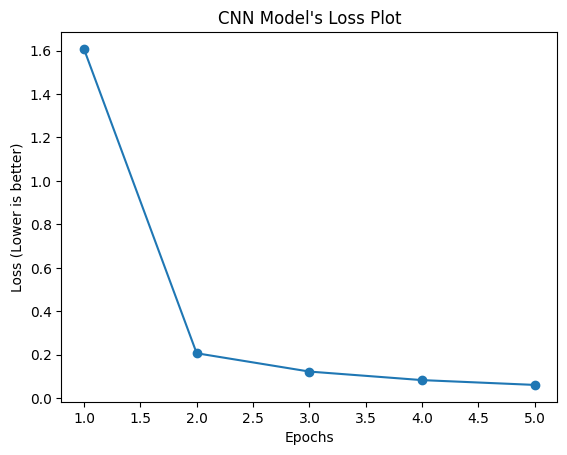

In [18]:
Line_Plot(Loss_Sigmoid_CNN.keys(), Loss_Sigmoid_CNN.values(), 'Epochs', 'Loss (Lower is better)', "CNN Model's Loss Plot")

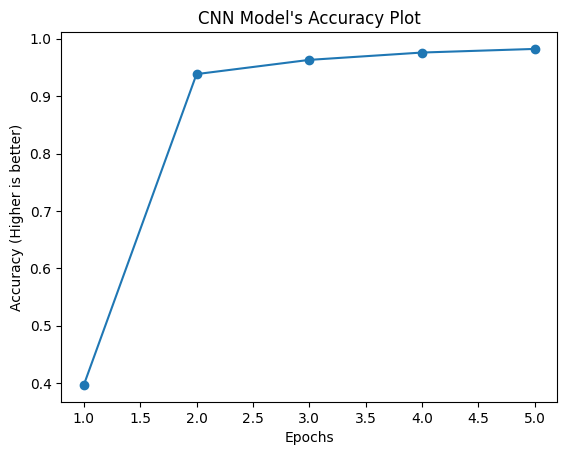

In [19]:
Line_Plot(Accuracy_Sigmoid_CNN.keys(), Accuracy_Sigmoid_CNN.values(), 'Epochs', 'Accuracy (Higher is better)', "CNN Model's Accuracy Plot")

In [20]:
Tester(model, test_loader)

Accuracy: 0.9798
Precision: 0.9799
Recall: 0.9798


### MLP-1

In [21]:
model = MLP(nn.Sigmoid())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

In [22]:
Tester(model, test_loader)

Accuracy: 0.0982
Precision: 0.0096
Recall: 0.0982


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
Loss_Sigmoid_MLP1, Accuracy_Sigmoid_MLP1 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.4628, Accuracy: = 0.8516
Epoch [2/5], Loss: 0.1435, Accuracy: = 0.9566
Epoch [3/5], Loss: 0.0914, Accuracy: = 0.9724
Epoch [4/5], Loss: 0.0660, Accuracy: = 0.9799
Epoch [5/5], Loss: 0.0463, Accuracy: = 0.9857


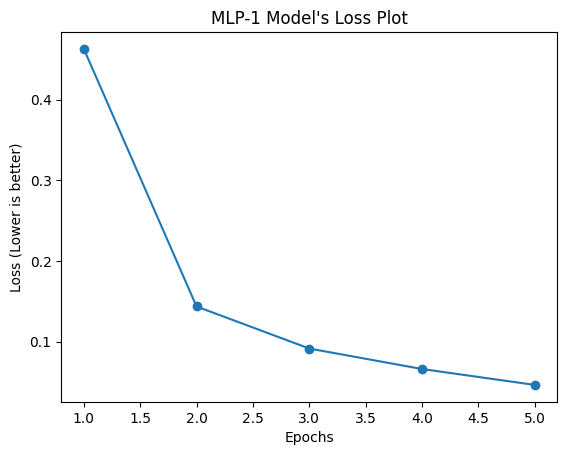

In [24]:
Line_Plot(Loss_Sigmoid_MLP1.keys(), Loss_Sigmoid_MLP1.values(), 'Epochs', 'Loss (Lower is better)', "MLP-1 Model's Loss Plot")

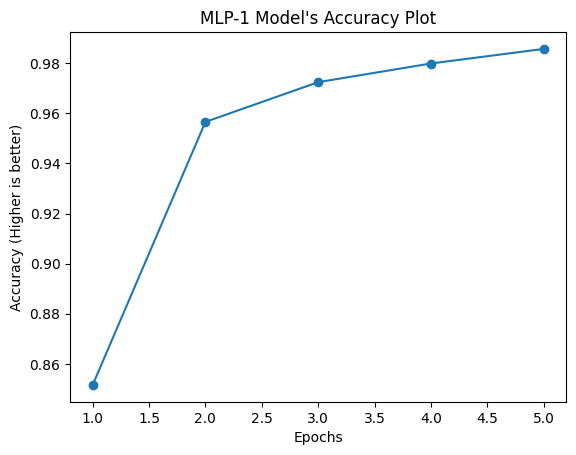

In [25]:
Line_Plot(Accuracy_Sigmoid_MLP1.keys(), Accuracy_Sigmoid_MLP1.values(), 'Epochs', 'Accuracy (Higher is better)', "MLP-1 Model's Accuracy Plot")

In [26]:
Tester(model, test_loader)

Accuracy: 0.9765
Precision: 0.9766
Recall: 0.9765


### MLP-2 (Note: One in Lab is Two for us)

In [27]:
model = MLP2(nn.Sigmoid())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

In [28]:
Tester(model, test_loader)

Accuracy: 0.1010
Precision: 0.0102
Recall: 0.1010


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [29]:
Loss_Sigmoid_MLP2, Accuracy_Sigmoid_MLP2 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.5091, Accuracy: = 0.8332
Epoch [2/5], Loss: 0.1813, Accuracy: = 0.9460
Epoch [3/5], Loss: 0.1285, Accuracy: = 0.9606
Epoch [4/5], Loss: 0.1014, Accuracy: = 0.9685
Epoch [5/5], Loss: 0.0863, Accuracy: = 0.9733


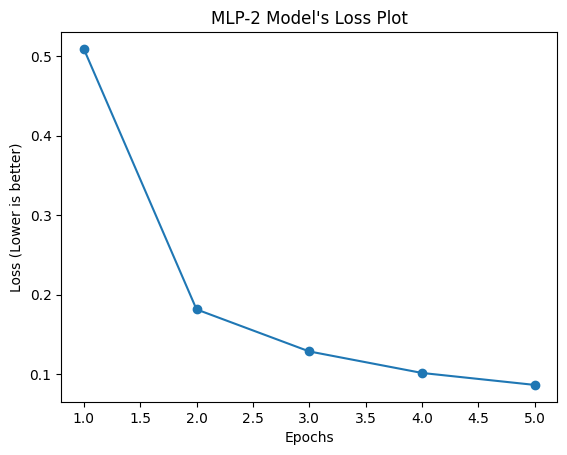

In [30]:
Line_Plot(Loss_Sigmoid_MLP2.keys(), Loss_Sigmoid_MLP2.values(), 'Epochs', 'Loss (Lower is better)', "MLP-2 Model's Loss Plot")

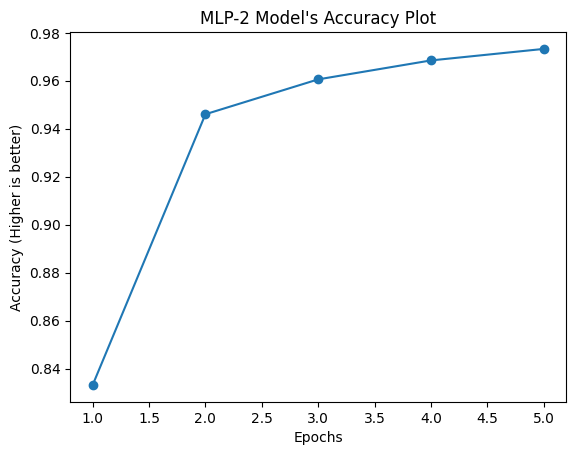

In [31]:
Line_Plot(Accuracy_Sigmoid_MLP2.keys(), Accuracy_Sigmoid_MLP2.values(), 'Epochs', 'Accuracy (Higher is better)', "MLP-2 Model's Accuracy Plot")

In [32]:
Tester(model, test_loader)

Accuracy: 0.9645
Precision: 0.9650
Recall: 0.9645


## RELU 

### CNN

In [33]:
model = CNN(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

In [34]:
Tester(model, test_loader)

Accuracy: 0.1433
Precision: 0.1018
Recall: 0.1433


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [35]:
Loss_ReLU_CNN, Accuracy_ReLU_CNN = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.2565, Accuracy: = 0.9213
Epoch [2/5], Loss: 0.0535, Accuracy: = 0.9837
Epoch [3/5], Loss: 0.0330, Accuracy: = 0.9899
Epoch [4/5], Loss: 0.0224, Accuracy: = 0.9930
Epoch [5/5], Loss: 0.0171, Accuracy: = 0.9944


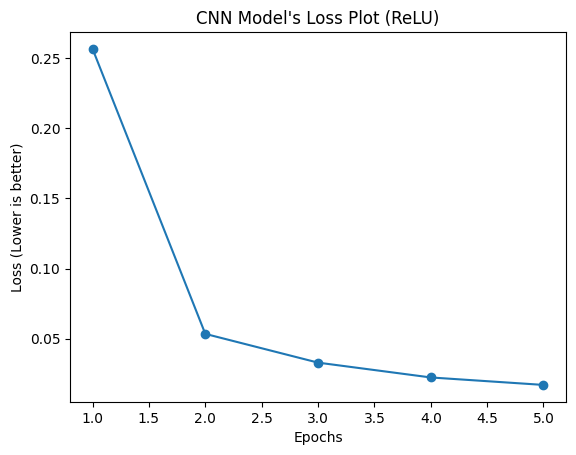

In [36]:
Line_Plot(Loss_ReLU_CNN.keys(), Loss_ReLU_CNN.values(), 'Epochs', 'Loss (Lower is better)', "CNN Model's Loss Plot (ReLU)")

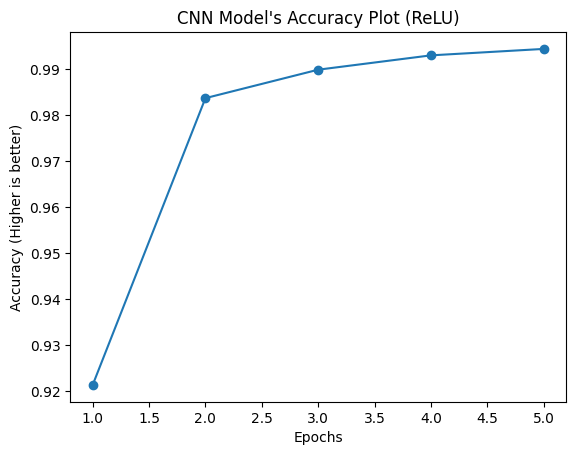

In [37]:
Line_Plot(Accuracy_ReLU_CNN.keys(), Accuracy_ReLU_CNN.values(), 'Epochs', 'Accuracy (Higher is better)', "CNN Model's Accuracy Plot (ReLU)")

### MLP-1

In [38]:
model = MLP(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

In [39]:
Tester(model, test_loader)

Accuracy: 0.1411
Precision: 0.0891
Recall: 0.1411


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [40]:
Loss_ReLU_MLP1, Accuracy_ReLU_MLP1 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.2868, Accuracy: = 0.9119
Epoch [2/5], Loss: 0.0983, Accuracy: = 0.9692
Epoch [3/5], Loss: 0.0667, Accuracy: = 0.9789
Epoch [4/5], Loss: 0.0503, Accuracy: = 0.9839
Epoch [5/5], Loss: 0.0381, Accuracy: = 0.9879


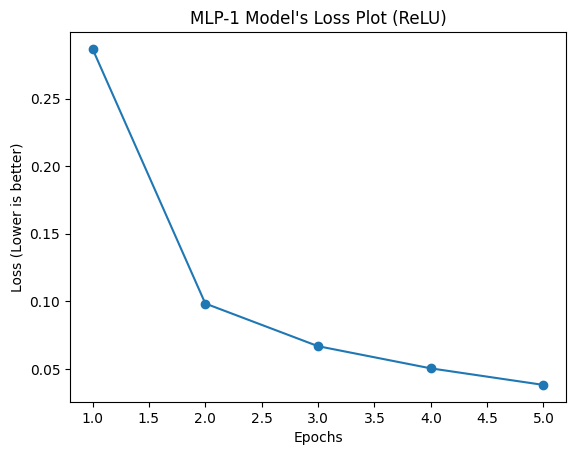

In [41]:
Line_Plot(Loss_ReLU_MLP1.keys(), Loss_ReLU_MLP1.values(), 'Epochs', 'Loss (Lower is better)', "MLP-1 Model's Loss Plot (ReLU)")

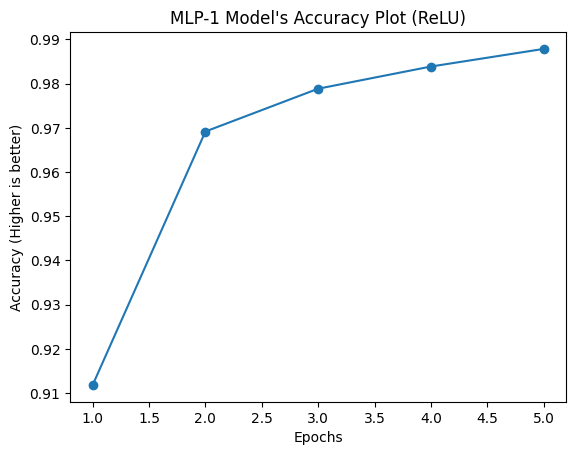

In [42]:
Line_Plot(Accuracy_ReLU_MLP1.keys(), Accuracy_ReLU_MLP1.values(), 'Epochs', 'Accuracy (Higher is better)', "MLP-1 Model's Accuracy Plot (ReLU)")

### MLP-2

In [43]:
model = MLP2(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [44]:
Tester(model, test_loader)

Accuracy: 0.0839
Precision: 0.0251
Recall: 0.0839


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [45]:
Loss_ReLU_MLP2, Accuracy_ReLU_MLP2 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.3172, Accuracy: = 0.9041
Epoch [2/5], Loss: 0.1211, Accuracy: = 0.9625
Epoch [3/5], Loss: 0.0828, Accuracy: = 0.9736
Epoch [4/5], Loss: 0.0621, Accuracy: = 0.9806
Epoch [5/5], Loss: 0.0483, Accuracy: = 0.9844


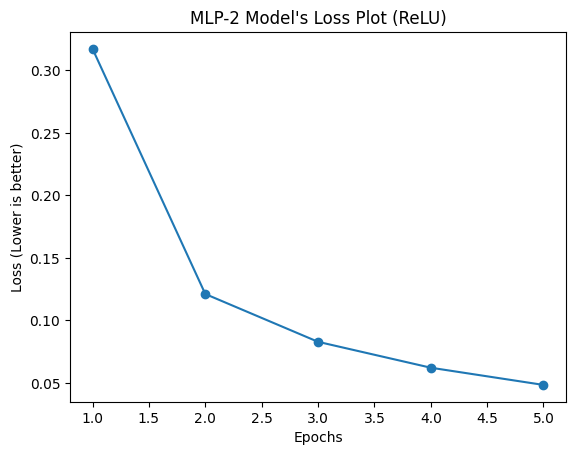

In [46]:
Line_Plot(Loss_ReLU_MLP2.keys(), Loss_ReLU_MLP2.values(), 'Epochs', 'Loss (Lower is better)', "MLP-2 Model's Loss Plot (ReLU)")

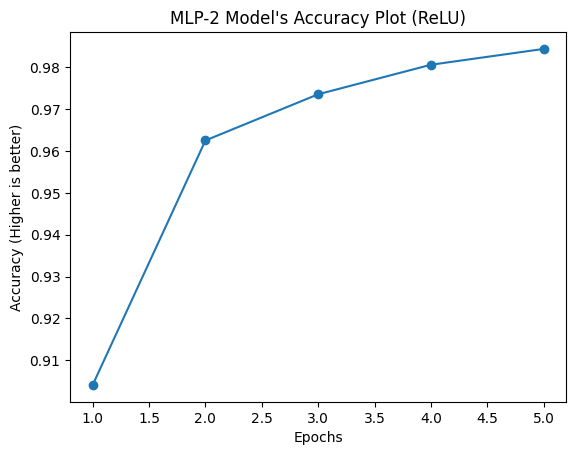

In [47]:
Line_Plot(Accuracy_ReLU_MLP2.keys(), Accuracy_ReLU_MLP2.values(), 'Epochs', 'Accuracy (Higher is better)', "MLP-2 Model's Accuracy Plot (ReLU)")

__NOTE: We have to remember that the lr for MLP-2 ReLU is 0.1 instead of the standard 0.5 due to the high overstep, the loss and thus learning, quickly results in degrading the model.__ 

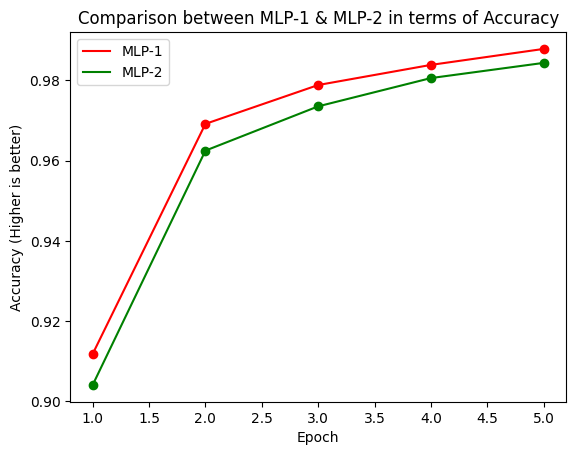

In [48]:
Line_Plot_Teams(X = [Accuracy_ReLU_MLP1.keys(), Accuracy_ReLU_MLP2.keys()], Y = [Accuracy_ReLU_MLP1.values(), Accuracy_ReLU_MLP2.values()], legend = ['MLP-1', 'MLP-2'], Xlabel = 'Epoch', Ylabel = 'Accuracy (Higher is better)', Title = 'Comparison between MLP-1 & MLP-2 in terms of Accuracy')

### Tanh

In [49]:
model = CNN(nn.Tanh())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

In [50]:
Tester(model, test_loader)

Accuracy: 0.1172
Precision: 0.1450
Recall: 0.1172


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [51]:
Loss_Tanh_CNN, Accuracy_Tanh_CNN = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 4.6759, Accuracy: = 0.5178
Epoch [2/5], Loss: 1.1851, Accuracy: = 0.7367
Epoch [3/5], Loss: 0.6812, Accuracy: = 0.8209
Epoch [4/5], Loss: 0.5819, Accuracy: = 0.8395
Epoch [5/5], Loss: 0.4656, Accuracy: = 0.8703


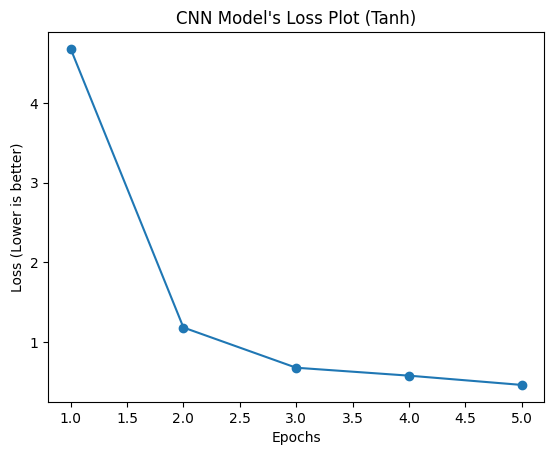

In [52]:
Line_Plot(Loss_Tanh_CNN.keys(), Loss_Tanh_CNN.values(), 'Epochs', 'Loss (Lower is better)', "CNN Model's Loss Plot (Tanh)")

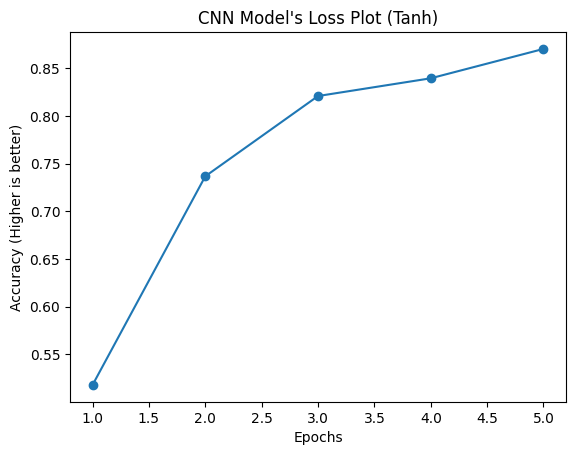

In [53]:
Line_Plot(Accuracy_Tanh_CNN.keys(), Accuracy_Tanh_CNN.values(), 'Epochs', 'Accuracy (Higher is better)', "CNN Model's Loss Plot (Tanh)")

In [54]:
Tester(model, test_loader)

Accuracy: 0.8751
Precision: 0.8880
Recall: 0.8751


### MLP-1 

In [55]:
model = MLP(nn.Tanh())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

In [56]:
Tester(model, test_loader)

Accuracy: 0.1126
Precision: 0.1208
Recall: 0.1126


In [57]:
Loss_Tanh_MLP1, Accuracy_Tanh_MLP1 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.2430, Accuracy: = 0.9247
Epoch [2/5], Loss: 0.1012, Accuracy: = 0.9691
Epoch [3/5], Loss: 0.0679, Accuracy: = 0.9788
Epoch [4/5], Loss: 0.0515, Accuracy: = 0.9829
Epoch [5/5], Loss: 0.0381, Accuracy: = 0.9877


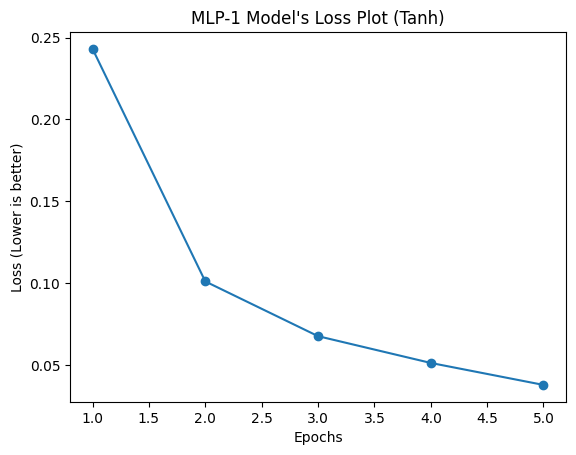

In [58]:
Line_Plot(Loss_Tanh_MLP1.keys(), Loss_Tanh_MLP1.values(), 'Epochs', 'Loss (Lower is better)', "MLP-1 Model's Loss Plot (Tanh)")

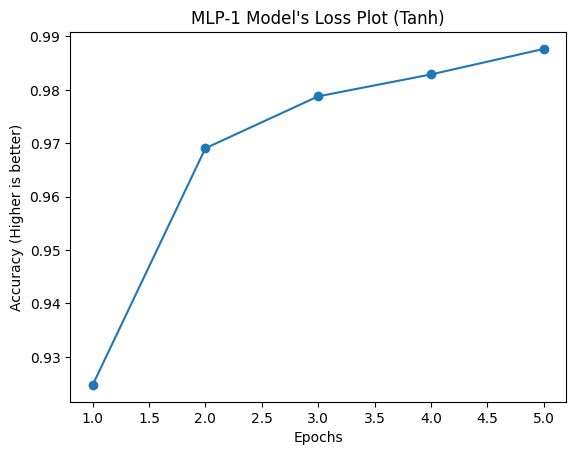

In [59]:
Line_Plot(Accuracy_Tanh_MLP1.keys(), Accuracy_Tanh_MLP1.values(), 'Epochs', 'Accuracy (Higher is better)', "MLP-1 Model's Loss Plot (Tanh)")

In [60]:
model = MLP2(nn.Tanh())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.5)

In [61]:
Tester(model, test_loader)

Accuracy: 0.1590
Precision: 0.1642
Recall: 0.1590


In [62]:
Loss_Tanh_MLP2, Accuracy_Tanh_MLP2 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.3341, Accuracy: = 0.9010
Epoch [2/5], Loss: 0.1563, Accuracy: = 0.9516
Epoch [3/5], Loss: 0.1303, Accuracy: = 0.9589
Epoch [4/5], Loss: 0.1161, Accuracy: = 0.9637
Epoch [5/5], Loss: 0.1113, Accuracy: = 0.9652


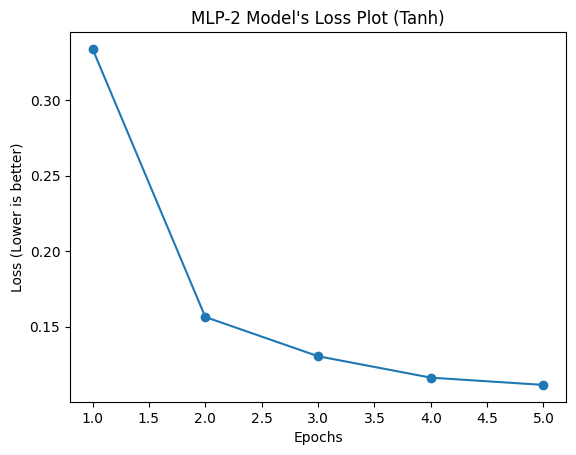

In [63]:
Line_Plot(Loss_Tanh_MLP2.keys(), Loss_Tanh_MLP2.values(), 'Epochs', 'Loss (Lower is better)', "MLP-2 Model's Loss Plot (Tanh)")

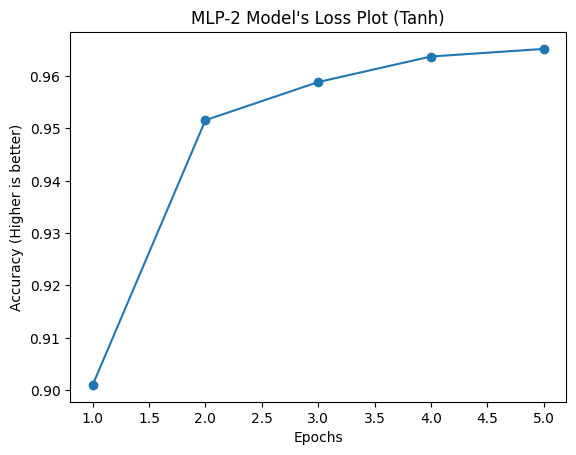

In [64]:
Line_Plot(Accuracy_Tanh_MLP2.keys(), Accuracy_Tanh_MLP2.values(), 'Epochs', 'Accuracy (Higher is better)', "MLP-2 Model's Loss Plot (Tanh)")

In [65]:
legend = ['Sigmoid', 'ReLU', 'Tanh']
Xlabel = 'Epoch'
Ylabel_loss = 'Loss (Lower is better)'
Ylabel_Accuracy = 'Accuracy (Higher is better)'

### Activation Functions Comprison - CNN 

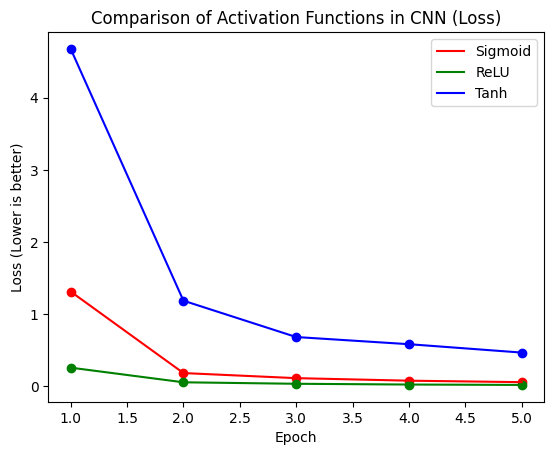

In [66]:
CNN_Loss_X = [Loss_Sigmoid_CNN.keys(), Loss_ReLU_CNN.keys(),Loss_Tanh_CNN.keys()]
CNN_Loss_y = [Loss_Sigmoid_CNN.values(), Loss_ReLU_CNN.values(),Loss_Tanh_CNN.values()]
Title = 'Comparison of Activation Functions in CNN (Loss)'
Line_Plot_Teams(X = CNN_Loss_X, Y = CNN_Loss_y, legend = legend, Xlabel = Xlabel, Ylabel = Ylabel_loss, Title = Title)

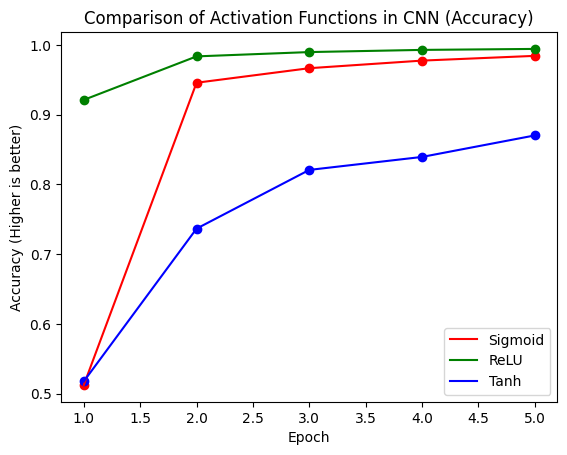

In [67]:
CNN_Accuracy_X = [Accuracy_Sigmoid_CNN.keys(), Accuracy_ReLU_CNN.keys(),Accuracy_Tanh_CNN.keys()]
CNN_Accuracy_y = [Accuracy_Sigmoid_CNN.values(), Accuracy_ReLU_CNN.values(),Accuracy_Tanh_CNN.values()]
Title = 'Comparison of Activation Functions in CNN (Accuracy)'
Line_Plot_Teams(X = CNN_Accuracy_X, Y = CNN_Accuracy_y, legend = legend, Xlabel = Xlabel, Ylabel = Ylabel_Accuracy, Title = Title)

### Activation Functions Comprison - MLP-1

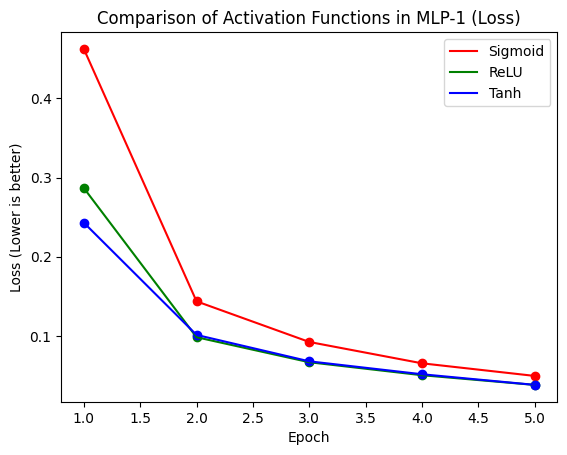

In [68]:
MLP1_Loss_X = [Loss_Sigmoid_MLP1.keys(), Loss_ReLU_MLP1.keys(),Loss_Tanh_MLP1.keys()]
MLP1_Loss_y = [Loss_Sigmoid_MLP1.values(), Loss_ReLU_MLP1.values(),Loss_Tanh_MLP1.values()]
Title = 'Comparison of Activation Functions in MLP-1 (Loss)'
Line_Plot_Teams(X = MLP1_Loss_X, Y = MLP1_Loss_y, legend = legend, Xlabel = Xlabel, Ylabel = Ylabel_loss, Title = Title)

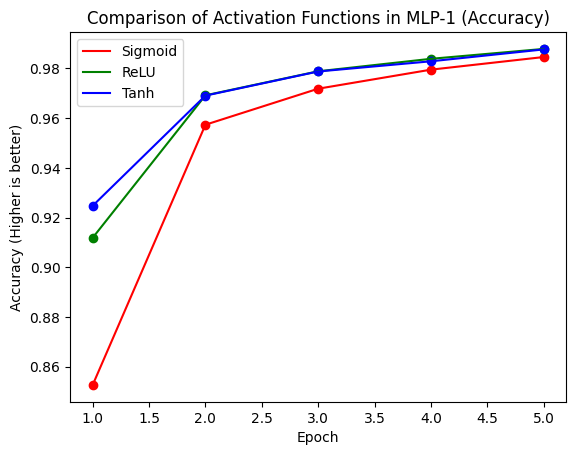

In [69]:
MLP1_Accuracy_X = [Accuracy_Sigmoid_MLP1.keys(), Accuracy_ReLU_MLP1.keys(),Accuracy_Tanh_MLP1.keys()]
MLP1_Accuracy_y = [Accuracy_Sigmoid_MLP1.values(), Accuracy_ReLU_MLP1.values(),Accuracy_Tanh_MLP1.values()]
Title = 'Comparison of Activation Functions in MLP-1 (Accuracy)'
Line_Plot_Teams(X = MLP1_Accuracy_X, Y = MLP1_Accuracy_y, legend = legend, Xlabel = Xlabel, Ylabel = Ylabel_Accuracy, Title = Title)

### Activation Functions Comprison - MLP-2 

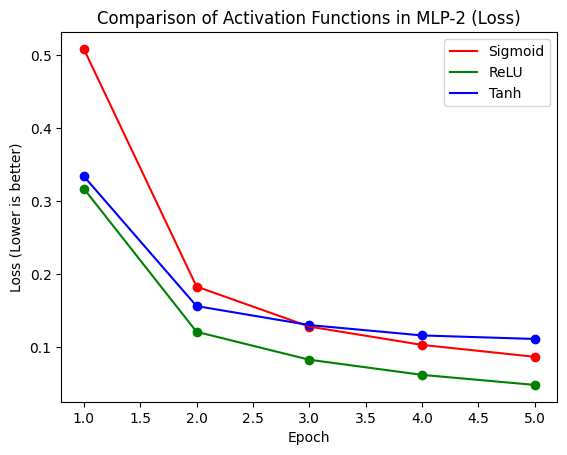

In [70]:
MLP2_Loss_X = [Loss_Sigmoid_MLP2.keys(), Loss_ReLU_MLP2.keys(),Loss_Tanh_MLP2.keys()]
MLP2_Loss_y = [Loss_Sigmoid_MLP2.values(), Loss_ReLU_MLP2.values(),Loss_Tanh_MLP2.values()]
Title = 'Comparison of Activation Functions in MLP-2 (Loss)'
Line_Plot_Teams(X = MLP2_Loss_X, Y = MLP2_Loss_y, legend = legend, Xlabel = Xlabel, Ylabel = Ylabel_loss, Title = Title)

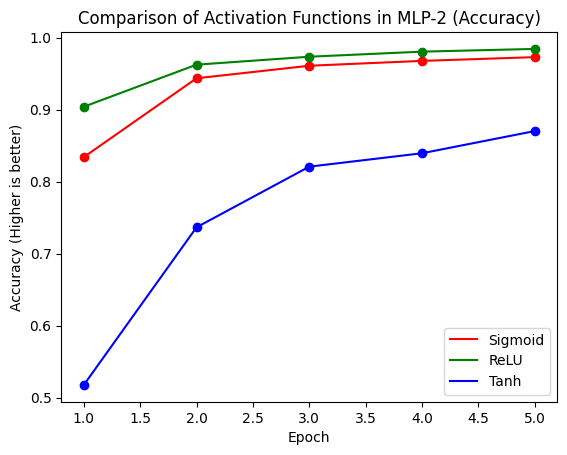

In [71]:
MLP2_Accuracy_X = [Accuracy_Sigmoid_MLP2.keys(), Accuracy_ReLU_MLP2.keys(),Accuracy_Tanh_CNN.keys()]
MLP2_Accuracy_y = [Accuracy_Sigmoid_MLP2.values(), Accuracy_ReLU_MLP2.values(),Accuracy_Tanh_CNN.values()]
Title = 'Comparison of Activation Functions in MLP-2 (Accuracy)'
Line_Plot_Teams(X = MLP2_Accuracy_X, Y = MLP2_Accuracy_y, legend = legend, Xlabel = Xlabel, Ylabel = Ylabel_Accuracy, Title = Title)

### Analysis

- Sigmoid: Be it the accuracies or the Erorrs/Losses, We find that Sigmoid fares well. We find no vanishing gradient issues in this particular study, btu that could be a issues like less number of epochs.
- Tanh: We find that Tanh converges in similar fashion to that of the Sigmoid function, but it is pretty vident that it performs less optimally compared to Sigmoid. Maybe given more epochs/iterations, it may improve, showing us that it converges slowly
- ReLU: We are able to see that ReLU consistently fares the best relative to the other ACtivation Functions. This is primarily due to the fact that ReLU is mostly a __if function__, meaning that its derivation is straight forward, being just a logical operation. But with Sigmoid for example, the backpropogation renders to be meaningless as we move down a large chain, but not ReLU. Hence ReLU is able works quick! 

# Task 2: The Optimizer Showdown
Once you have selected the best activation function, keep it constant and switch between these optimizers:
- SGD (Stochastic Gradient Descent): Observe the stability of the loss.
- SGD with Momentum: Note how it handles "bumps" in the loss landscape.
- Adam: Observe how quickly it reaches high accuracy compared to basic SGD.

In [88]:
legend = ['SGD', 'SGD-M', 'Adam']
Xlabel = 'Epoch'
Ylabel_loss = 'Loss (Lower is better)'
Ylabel_Accuracy = 'Accuracy (Higher is better)'

### SGD

In [51]:
model = CNN(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.2)

In [52]:
Tester(model, test_loader)

Accuracy: 0.1013
Precision: 0.0232
Recall: 0.1013


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [53]:
Loss_SGD_CNN, Accuracy_SGD_CNN = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.1585, Accuracy: = 0.9505
Epoch [2/5], Loss: 0.0404, Accuracy: = 0.9869
Epoch [3/5], Loss: 0.0247, Accuracy: = 0.9923
Epoch [4/5], Loss: 0.0163, Accuracy: = 0.9947
Epoch [5/5], Loss: 0.0111, Accuracy: = 0.9963


In [54]:
Tester(model, test_loader)

Accuracy: 0.9905
Precision: 0.9905
Recall: 0.9905


In [45]:
model = MLP(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), momentum = 0.5, lr = 0.2)

In [46]:
Tester(model, test_loader)

Accuracy: 0.0876
Precision: 0.0618
Recall: 0.0876


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [47]:
Loss_SGD_MLP1, Accuracy_SGD_MLP1 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.2173, Accuracy: = 0.9344
Epoch [2/5], Loss: 0.0868, Accuracy: = 0.9732
Epoch [3/5], Loss: 0.0560, Accuracy: = 0.9823
Epoch [4/5], Loss: 0.0389, Accuracy: = 0.9878
Epoch [5/5], Loss: 0.0320, Accuracy: = 0.9893


In [48]:
model = MLP2(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), momentum = 0.5, lr = 0.2)

In [49]:
Tester(model, test_loader)

Accuracy: 0.1152
Precision: 0.0858
Recall: 0.1152


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
Loss_SGD_MLP2, Accuracy_SGD_MLP2 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.2821, Accuracy: = 0.9135
Epoch [2/5], Loss: 0.1278, Accuracy: = 0.9613
Epoch [3/5], Loss: 0.0941, Accuracy: = 0.9709
Epoch [4/5], Loss: 0.0728, Accuracy: = 0.9771
Epoch [5/5], Loss: 0.0601, Accuracy: = 0.9818


### SGD with Momentum 

In [55]:
model = CNN(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.2, momentum = 0.5)

In [56]:
Tester(model, test_loader)

Accuracy: 0.0924
Precision: 0.0159
Recall: 0.0924


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [57]:
Loss_SGDM_CNN, Accuracy_SGDM_CNN = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.1397, Accuracy: = 0.9578
Epoch [2/5], Loss: 0.0414, Accuracy: = 0.9871
Epoch [3/5], Loss: 0.0254, Accuracy: = 0.9918
Epoch [4/5], Loss: 0.0170, Accuracy: = 0.9946
Epoch [5/5], Loss: 0.0118, Accuracy: = 0.9961


In [58]:
Tester(model, test_loader)

Accuracy: 0.9885
Precision: 0.9885
Recall: 0.9885


In [59]:
model = MLP(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.2, momentum = 0.5)

In [60]:
Tester(model, test_loader)

Accuracy: 0.0915
Precision: 0.0705
Recall: 0.0915


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [61]:
Loss_SGDM_MLP1, Accuracy_SGDM_MLP1 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.2211, Accuracy: = 0.9326
Epoch [2/5], Loss: 0.0852, Accuracy: = 0.9740
Epoch [3/5], Loss: 0.0595, Accuracy: = 0.9810
Epoch [4/5], Loss: 0.0414, Accuracy: = 0.9871
Epoch [5/5], Loss: 0.0271, Accuracy: = 0.9911


In [62]:
Tester(model, test_loader)

Accuracy: 0.9760
Precision: 0.9763
Recall: 0.9760


In [63]:
model = MLP2(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.2, momentum = 0.5)

In [64]:
Tester(model, test_loader)

Accuracy: 0.0852
Precision: 0.0673
Recall: 0.0852


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [65]:
Loss_SGDM_MLP2, Accuracy_SGDM_MLP2 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.3008, Accuracy: = 0.9088
Epoch [2/5], Loss: 0.1321, Accuracy: = 0.9596
Epoch [3/5], Loss: 0.0941, Accuracy: = 0.9707
Epoch [4/5], Loss: 0.0727, Accuracy: = 0.9772
Epoch [5/5], Loss: 0.0602, Accuracy: = 0.9805


In [66]:
Tester(model, test_loader)

Accuracy: 0.9745
Precision: 0.9746
Recall: 0.9745


### Adam 

In [103]:
model = CNN(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [104]:
Tester(model, test_loader)a

Accuracy: 0.0624
Precision: 0.0234
Recall: 0.0624


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [105]:
Loss_Adam_CNN, Accuracy_Adam_CNN = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.1110, Accuracy: = 0.9659
Epoch [2/5], Loss: 0.0365, Accuracy: = 0.9888
Epoch [3/5], Loss: 0.0216, Accuracy: = 0.9930
Epoch [4/5], Loss: 0.0149, Accuracy: = 0.9949
Epoch [5/5], Loss: 0.0115, Accuracy: = 0.9961


In [102]:
Tester(model, test_loader)

Accuracy: 0.1028
Precision: 0.0106
Recall: 0.1028


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [106]:
model = MLP(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [107]:
Tester(model, test_loader)

Accuracy: 0.0809
Precision: 0.0848
Recall: 0.0809


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [108]:
Loss_Adam_MLP1, Accuracy_Adam_MLP1 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.2298, Accuracy: = 0.9304
Epoch [2/5], Loss: 0.0904, Accuracy: = 0.9728
Epoch [3/5], Loss: 0.0650, Accuracy: = 0.9794
Epoch [4/5], Loss: 0.0481, Accuracy: = 0.9847
Epoch [5/5], Loss: 0.0398, Accuracy: = 0.9872


In [109]:
Tester(model, test_loader)

Accuracy: 0.9766
Precision: 0.9768
Recall: 0.9766


In [110]:
model = MLP2(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [111]:
Tester(model, test_loader)

Accuracy: 0.0950
Precision: 0.0580
Recall: 0.0950


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [112]:
Loss_Adam_MLP2, Accuracy_Adam_MLP2 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.2582, Accuracy: = 0.9213
Epoch [2/5], Loss: 0.1279, Accuracy: = 0.9602
Epoch [3/5], Loss: 0.1005, Accuracy: = 0.9686
Epoch [4/5], Loss: 0.0827, Accuracy: = 0.9732
Epoch [5/5], Loss: 0.0719, Accuracy: = 0.9773


In [113]:
Tester(model, test_loader)

Accuracy: 0.9719
Precision: 0.9722
Recall: 0.9719


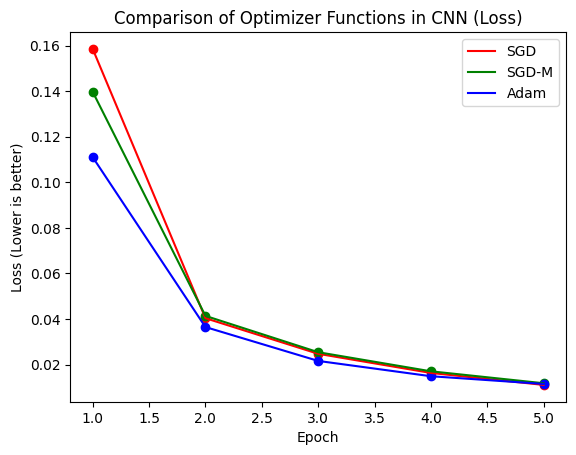

In [114]:
CNN_Loss_X = [Loss_SGD_CNN.keys(), Loss_SGDM_CNN.keys(),Loss_Adam_CNN.keys()]
CNN_Loss_y = [Loss_SGD_CNN.values(), Loss_SGDM_CNN.values(),Loss_Adam_CNN.values()]
Title = 'Comparison of Optimizer Functions in CNN (Loss)'
Line_Plot_Teams(X = CNN_Loss_X, Y = CNN_Loss_y, legend = legend, Xlabel = Xlabel, Ylabel = Ylabel_loss, Title = Title)

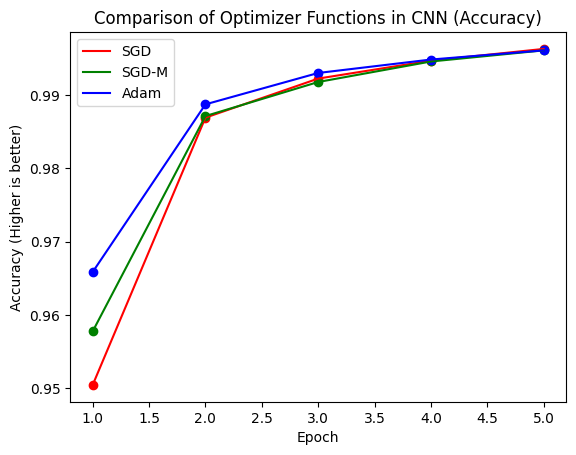

In [115]:
CNN_Accuracy_X = [Accuracy_SGD_CNN.keys(), Accuracy_SGDM_CNN.keys(),Accuracy_Adam_CNN.keys()]
CNN_Accuracy_y = [Accuracy_SGD_CNN.values(), Accuracy_SGDM_CNN.values(),Accuracy_Adam_CNN.values()]
Title = 'Comparison of Optimizer Functions in CNN (Accuracy)'
Line_Plot_Teams(X = CNN_Accuracy_X, Y = CNN_Accuracy_y, legend = legend, Xlabel = Xlabel, Ylabel = Ylabel_Accuracy, Title = Title)

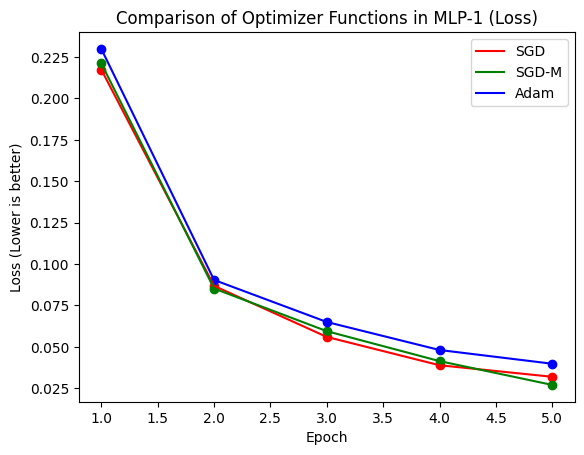

In [116]:
MLP1_Loss_X = [Loss_SGD_MLP1.keys(), Loss_SGDM_MLP1.keys(),Loss_Adam_MLP1.keys()]
MLP1_Loss_y = [Loss_SGD_MLP1.values(), Loss_SGDM_MLP1.values(),Loss_Adam_MLP1.values()]
Title = 'Comparison of Optimizer Functions in MLP-1 (Loss)'
Line_Plot_Teams(X = MLP1_Loss_X, Y = MLP1_Loss_y, legend = legend, Xlabel = Xlabel, Ylabel = Ylabel_loss, Title = Title)

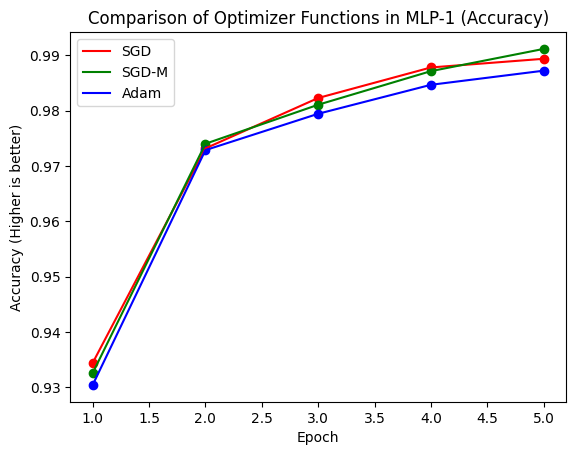

In [117]:
MLP1_Accuracy_X = [Accuracy_SGD_MLP1.keys(), Accuracy_SGDM_MLP1.keys(),Accuracy_Adam_MLP1.keys()]
MLP1_Accuracy_y = [Accuracy_SGD_MLP1.values(), Accuracy_SGDM_MLP1.values(),Accuracy_Adam_MLP1.values()]
Title = 'Comparison of Optimizer Functions in MLP-1 (Accuracy)'
Line_Plot_Teams(X = MLP1_Accuracy_X, Y = MLP1_Accuracy_y, legend = legend, Xlabel = Xlabel, Ylabel = Ylabel_Accuracy, Title = Title)

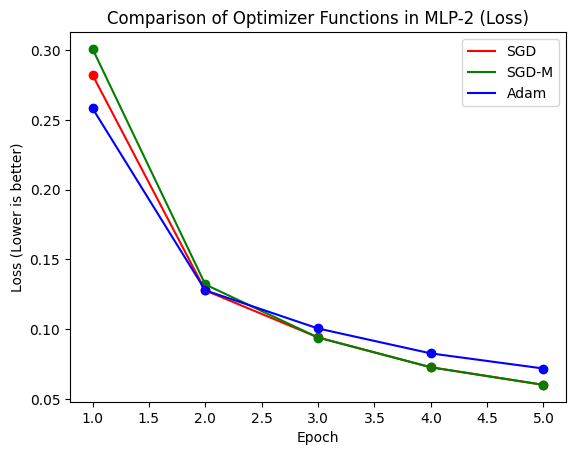

In [118]:
MLP2_Loss_X = [Loss_SGD_MLP2.keys(), Loss_SGDM_MLP2.keys(),Loss_Adam_MLP2.keys()]
MLP2_Loss_y = [Loss_SGD_MLP2.values(), Loss_SGDM_MLP2.values(),Loss_Adam_MLP2.values()]
Title = 'Comparison of Optimizer Functions in MLP-2 (Loss)'
Line_Plot_Teams(X = MLP2_Loss_X, Y = MLP2_Loss_y, legend = legend, Xlabel = Xlabel, Ylabel = Ylabel_loss, Title = Title)

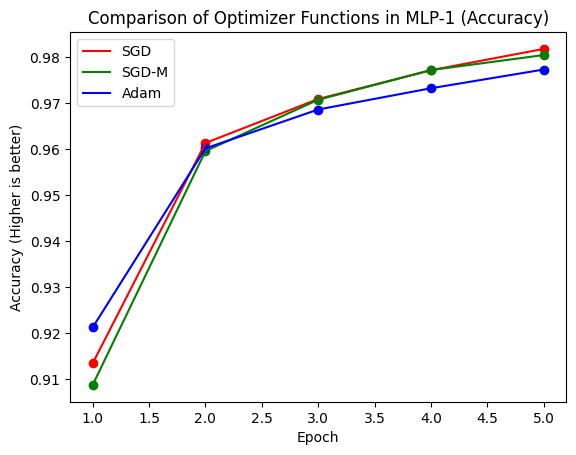

In [119]:
MLP2_Accuracy_X = [Accuracy_SGD_MLP2.keys(), Accuracy_SGDM_MLP2.keys(),Accuracy_Adam_MLP2.keys()]
MLP2_Accuracy_y = [Accuracy_SGD_MLP2.values(), Accuracy_SGDM_MLP2.values(),Accuracy_Adam_MLP2.values()]
Title = 'Comparison of Optimizer Functions in MLP-1 (Accuracy)'
Line_Plot_Teams(X = MLP2_Accuracy_X, Y = MLP2_Accuracy_y, legend = legend, Xlabel = Xlabel, Ylabel = Ylabel_Accuracy, Title = Title)

### Analysis 

- SGD (Stochastic Gradient Descent): We find that the Loss for SGD in this particular study isn't stable, but rather reduces quickly with each iterations. But it is safe to assume that beyond the 5th epoch, consier the 10th epoch, we can find that th loss would be very minutely changing and stable. 

- SGD with Momentum: In this particular analysis this is no 'bumps' and we find that SGD and SGS-M perform simlarly with SGD being better in some cases

- Adam: Comparing it to SGD, would be unfair, as we're considering different rates of learning in this example, which is necessary as we increase the number of epochs. But putting this aside, we find that Adam finds the optimal configurations and areas of higher accuracies slightly quicker than SGD ven consider the difference in learning rate! Possibly due to the considerations of previous knowledge as well

In [15]:
class MLP3(nn.Module):
    def __init__(self, Function, name = 'MLP model'):
        super().__init__()
        self.Dense1 = nn.Linear(28*28, 256)
        #self.BN1 = nn.BatchNorm1d(256)
        self.Dense2 = nn.Linear(256, 128)
        #self.BN2 = nn.BatchNorm1d(128)
        self.Dense3 = nn.Linear(128, 10)
        self.Function = Function
        self.name = name

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        x = self.Function(self.Dense1(x))
        #x = self.BN1(x)
        x = self.Function(self.Dense2(x))
        #x = self.BN2(x)
        x = self.Dense3(x)
        return x  # logits, apply softmax outside if needed


In [16]:
class MLP4(nn.Module):
    def __init__(self, Function, name = 'MLP model'):
        super().__init__()
        self.Dense1 = nn.Linear(28*28, 256)
        #self.BN1 = nn.BatchNorm1d(256)
        self.Dense2 = nn.Linear(256, 128)
        #self.BN2 = nn.BatchNorm1d(128)
        self.Dense3 = nn.Linear(128, 10)
        self.Function = Function
        self.name = name
        self.dropout = nn.Dropout(p=0.1)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        x = self.Function(self.Dense1(x))
        #x = self.BN1(x)
        x = self.Function(self.Dense2(x))
        x = self.dropout(x)
        #x = self.BN2(x)
        x = self.Dense3(x)
        return x  # logits, apply softmax outside if needed


In [31]:
class MLP5(nn.Module):
    def __init__(self, Function, name = 'MLP model'):
        super().__init__()
        self.Dense1 = nn.Linear(28*28, 256)
        self.BN1 = nn.BatchNorm1d(256)
        self.Dense2 = nn.Linear(256, 128)
        self.BN2 = nn.BatchNorm1d(128)
        self.Dense3 = nn.Linear(128, 10)
        self.Function = Function
        self.name = name
        self.dropout = nn.Dropout(p=0.25)

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten
        x = self.Function(self.Dense1(x))
        x = self.BN1(x)
        x = self.Function(self.Dense2(x))
        x = self.dropout(x)
        x = self.BN2(x)
        x = self.Dense3(x)
        return x  # logits, apply softmax outside if needed


In [18]:
model = MLP3(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [19]:
Tester(model, test_loader)

Accuracy: 0.1055
Precision: 0.1014
Recall: 0.1055


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
Loss_Adam_MLP3, Accuracy_Adam_MLP3 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.2293, Accuracy: = 0.9306
Epoch [2/5], Loss: 0.0947, Accuracy: = 0.9706
Epoch [3/5], Loss: 0.0647, Accuracy: = 0.9785
Epoch [4/5], Loss: 0.0492, Accuracy: = 0.9848
Epoch [5/5], Loss: 0.0401, Accuracy: = 0.9872


In [21]:
Tester(model, test_loader)

Accuracy: 0.9637
Precision: 0.9651
Recall: 0.9637


In [22]:
model = MLP4(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [23]:
Tester(model, test_loader)

Accuracy: 0.1020
Precision: 0.0897
Recall: 0.1020


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
Loss_Adam_MLP4, Accuracy_Adam_MLP4 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.2332, Accuracy: = 0.9291
Epoch [2/5], Loss: 0.0918, Accuracy: = 0.9721
Epoch [3/5], Loss: 0.0655, Accuracy: = 0.9793
Epoch [4/5], Loss: 0.0490, Accuracy: = 0.9841
Epoch [5/5], Loss: 0.0396, Accuracy: = 0.9869


In [25]:
Tester(model, test_loader)

Accuracy: 0.9773
Precision: 0.9775
Recall: 0.9773


In [32]:
model = MLP5(nn.ReLU())
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [33]:
Tester(model, test_loader)

Accuracy: 0.0397
Precision: 0.0268
Recall: 0.0397


C:\Users\jodya\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
Loss_Adam_MLP5, Accuracy_Adam_MLP5 = Trainer(5, loss_fn, optimizer, model, train_loader)

Epoch [1/5], Loss: 0.2292, Accuracy: = 0.9304
Epoch [2/5], Loss: 0.0925, Accuracy: = 0.9706
Epoch [3/5], Loss: 0.0641, Accuracy: = 0.9794
Epoch [4/5], Loss: 0.0493, Accuracy: = 0.9840
Epoch [5/5], Loss: 0.0386, Accuracy: = 0.9872


In [35]:
Tester(model, test_loader)

Accuracy: 0.9801
Precision: 0.9802
Recall: 0.9801


In [36]:
legend = ['None', 'Dropout', 'Drouput & BatchNorm']
Xlabel = 'Epoch'
Ylabel_loss = 'Loss (Lower is better)'
Ylabel_Accuracy = 'Accuracy (Higher is better)'

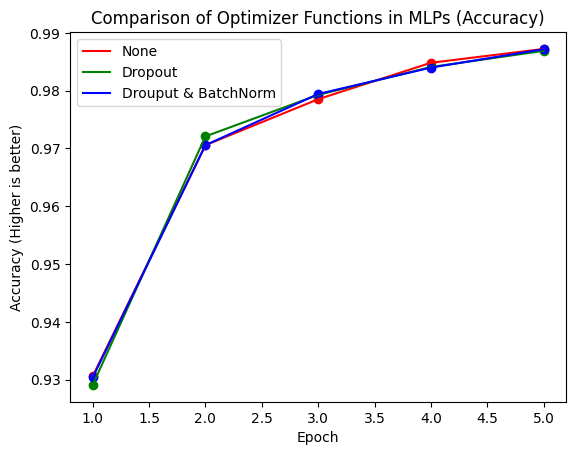

In [37]:
MLP_Accuracy_X = [Accuracy_Adam_MLP3.keys(), Accuracy_Adam_MLP4.keys(),Accuracy_Adam_MLP5.keys()]
MLP_Accuracy_y = [Accuracy_Adam_MLP3.values(), Accuracy_Adam_MLP4.values(),Accuracy_Adam_MLP5.values()]
Title = 'Comparison of Optimizer Functions in MLPs (Accuracy)'
Line_Plot_Teams(X = MLP_Accuracy_X, Y = MLP_Accuracy_y, legend = legend, Xlabel = Xlabel, Ylabel = Ylabel_Accuracy, Title = Title)

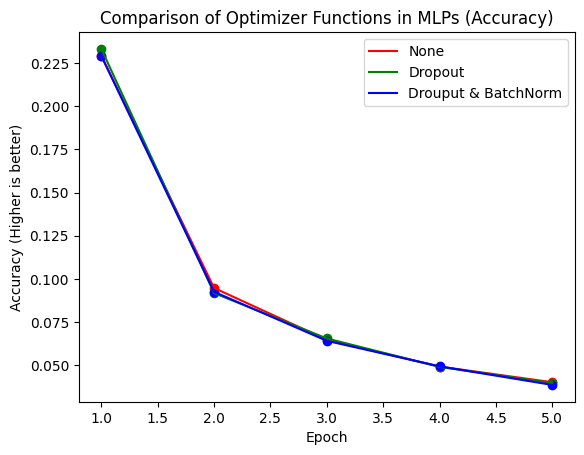

In [38]:
MLP_Loss_X = [Loss_Adam_MLP3.keys(), Loss_Adam_MLP4.keys(), Loss_Adam_MLP5.keys()]
MLP_Loss_y = [Loss_Adam_MLP3.values(), Loss_Adam_MLP4.values(), Loss_Adam_MLP5.values()]
Title = 'Comparison of Optimizer Functions in MLPs (Accuracy)'
Line_Plot_Teams(X = MLP_Loss_X, Y = MLP_Loss_y, legend = legend, Xlabel = Xlabel, Ylabel = Ylabel_Accuracy, Title = Title)